# Hi-C data analysis workshop (part 3: hicstuff interface)
Aurèle Piazza, Romain Bulteau

09/2026

---





## Overview
In this section, we will see how to

 - load a cool object with the [`hicstuff`](https://hicstuff.readthedocs.io/en/latest/index.html) python API
 - manipulate, normalize, plot Hi-C data
 - recreate a set of publication HiC maps

## Setup

Since each notebook is in its own environment, we need to install the dependencies and fetch the data we need for the course at the start of each notebook.

You can go to the Table of contents (on the left) and click the 'play' symbol next to the Setup section to run the whole section at once.

### Install & check dependencies

In [1]:
!pip install cooler cooltools hicstuff==3.2.4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 17.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.3/109.3 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 108.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 100.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 103.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.6/25.6 MB 84.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 876.2/876.2 kB 46.8 MB/s eta 0:00:00
  Created wheel for cooltools: filename=cooltools-0.7.1-cp313-cp313

In [2]:
import os
import cooler
import numpy as np
import hicstuff.io as hio
import hicstuff.view as hcv
import hicstuff.hicstuff as hcs
import hicstuff.version as hcs_v
import hicstuff.distance_law as hdl
from cooltools.lib.numutils import coarsen
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm

# version check
print(f"hicstuff: {hcs_v.__version__}")
print(f"cooler: {cooler.__version__}")
print(f"numpy: {np.__version__}")

hicstuff: 3.2.4
cooler: 0.10.4
numpy: 2.1.3


### Download course data

In [3]:
# path to a folder on your drive where data will be saved
inputdir="hic_data/"
os.makedirs(inputdir, exist_ok=True) # create dir if not exist

# URLs to fetch the data
hicstuff_output_url = "https://sdrive.cnrs.fr/public.php/dav/files/xbqPnPwdEg7WMFd"
cool_url = "https://sdrive.cnrs.fr/public.php/dav/files/HXEWiinMcrPsTJw"

In [4]:
# subfolders with unzipped data (don't modify)
hicstuff_output_folder = f"{inputdir}/AD281_0.02_subsamp/"
cool_folder = f"{inputdir}/cool/"


# download & unzip data if subfolders are missing
if not os.path.isdir(hicstuff_output_folder):
  !wget {hicstuff_output_url}/?accept=zip -O {inputdir}/hcs_data.zip
  !unzip {inputdir}/hcs_data.zip -d {inputdir}

if not os.path.isdir(cool_folder):
  !wget {cool_url}/?accept=zip -O {inputdir}/cool.zip
  !unzip {inputdir}/cool.zip -d {inputdir}



--2026-09-02 13:00:11--  https://sdrive.cnrs.fr/public.php/dav/files/xbqPnPwdEg7WMFd/?accept=zip
Resolving sdrive.cnrs.fr (sdrive.cnrs.fr)... 193.55.86.34
Connecting to sdrive.cnrs.fr (sdrive.cnrs.fr)|193.55.86.34|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘hic_data//hcs_data.zip’

hic_data//hcs_data.     [                <=> ]  63.85M  1.46MB/s    in 74s     

2026-09-02 13:01:26 (881 KB/s) - ‘hic_data//hcs_data.zip’ saved [66952345]

Archive:  hic_data//hcs_data.zip
   creating: hic_data/AD281_0.02_subsamp/
   creating: hic_data/AD281_0.02_subsamp/plots/
 extracting: hic_data/AD281_0.02_subsamp/plots/event_distribution.pdf  
 extracting: hic_data/AD281_0.02_subsamp/plots/distance_law.pdf  
 extracting: hic_data/AD281_0.02_subsamp/plots/event_distance.pdf  
 extracting: hic_data/AD281_0.02_subsamp/plots/frags_hist.pdf  
 extracting: hic_data/AD281_0.02_subsamp/info_contigs.txt  
 extracting: hic_data/AD281_0.02_su

## Library & sample loading

In [5]:
# path to the output from the hicstuff pipeline
# path to the 'Cool' folder from the hicstuff pipeline
hcs_folder=f"{hicstuff_output_folder}/Cool/"
hcs_sample="AD281_0.02_subsamp_S288c_DSB_chr3_rDNA_parasplit_q20_v324"

# path to a folder on your drive where files/plots will be saved
outputdir="outputs/part3/"
os.makedirs(outputdir, exist_ok=True) # create dir if not exist

# path to the workshop cool files
cooldir=f"{cool_folder}"

# list of sample names
samples=[
    "AD24_AD95_AD96_AD97_AD161_AD392to400_merged_S288c_DSB_chr3_rDNA_cutsite_q20",  # Asynchronous
    "AD281_AD285_AD337_AD363_S288c_DSB_chr3_rDNA_cutsite_q20_v312",                 # DSB, 4h
    "AD265_AD266_merged_S288c_DSB_chr3_rDNA_cutsite_q20"                            # Metaphase-arrested
]


# color map for plotting
cmap = plt.get_cmap("YlOrBr")
cmap.set_bad('white')

------

## Loading cool files with hicstuff

[`hicstuff`](https://hicstuff.readthedocs.io/en/latest/index.html) provides a more flexible loading interface and functions for easier downstream analysis.
We will use hicstuff for the remainder of the workshop.

The cool loading syntax is slightly different from cooler :

In [6]:
# path to the cool file
cool_file=f'{hcs_folder}{hcs_sample}_1kb.cool'

mat, frags, chroms = hio.flexible_hic_loader(cool_file)

  frags["id"] = frags.groupby("chrom", sort=False).cumcount() + 1

  frags["id"] = frags.groupby("chrom", sort=False).cumcount() + 1

  n_frags = c.bins()[:].groupby("chrom", sort=False).count().start

  n_frags = c.bins()[:].groupby("chrom", sort=False).count().start



The loader returns the `mat`, `chr`, and `chrom` objects, which correspond to the 3 main outputs of the pipeline seen in part 1.

In [7]:
print(mat)
print(frags)
print(chroms)
mat.sum()

<COOrdinate sparse matrix of dtype 'int32'
	with 492969 stored elements and shape (12166, 12166)>
  Coords	Values
  (0, 0)	3
  (0, 1)	3
  (0, 2)	4
  (0, 3)	3
  (0, 4)	1
  (0, 5)	6
  (0, 6)	4
  (0, 7)	1
  (0, 8)	7
  (0, 9)	1
  (0, 13)	1
  (0, 14)	5
  (0, 15)	1
  (0, 17)	3
  (0, 18)	1
  (0, 20)	2
  (0, 27)	2
  (0, 28)	2
  (0, 31)	1
  (0, 34)	2
  (0, 38)	3
  (0, 44)	2
  (0, 45)	1
  (0, 46)	2
  (0, 48)	1
  :	:
  (12139, 12146)	1
  (12139, 12148)	1
  (12139, 12152)	1
  (12139, 12154)	2
  (12139, 12155)	1
  (12139, 12158)	1
  (12139, 12159)	2
  (12141, 12141)	1
  (12141, 12145)	1
  (12142, 12164)	1
  (12145, 12153)	1
  (12145, 12154)	1
  (12145, 12156)	1
  (12145, 12158)	1
  (12145, 12159)	1
  (12145, 12160)	1
  (12146, 12164)	1
  (12147, 12154)	1
  (12147, 12159)	2
  (12153, 12158)	2
  (12154, 12158)	2
  (12154, 12160)	1
  (12155, 12156)	1
  (12156, 12158)	1
  (12156, 12159)	1
       id          chrom  start_pos  end_pos  size  gc_content
0       1           chr1          0     1000  1000  

np.int64(1065569)

Let's normalize and plot maps, as done in the previous part.

In [8]:
# normalize
norm_mat = hcs.normalize_sparse(mat, norm='SCN', iterations=40, n_mad=30)

  im = ax1.imshow(np.log10(submat), cmap=cmap)

  im = ax1.imshow(np.log10(submat), cmap=cmap)

  im = ax2.imshow(np.log10(submat_norm), cmap=cmap)

  im = ax2.imshow(np.log10(submat_norm), cmap=cmap)



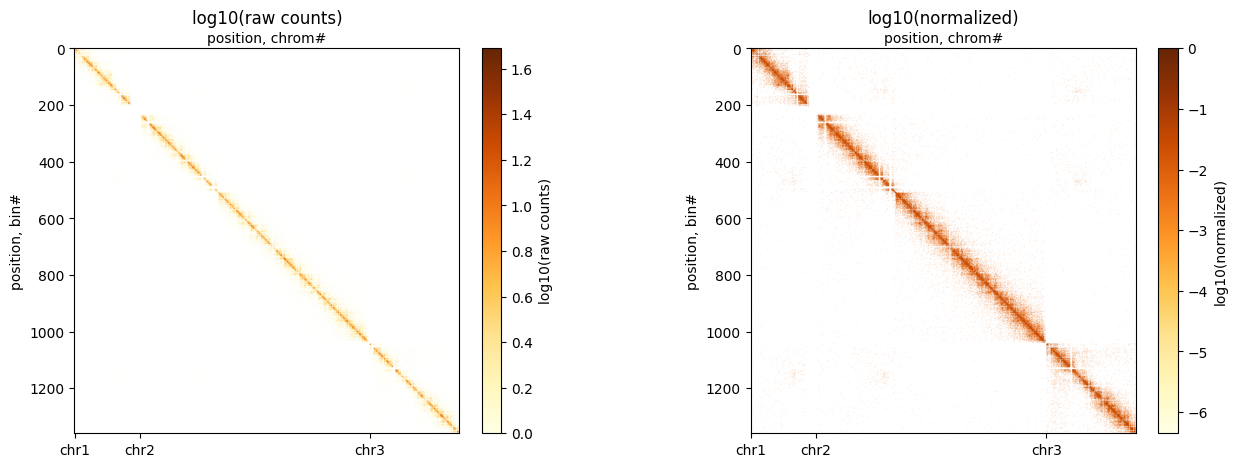

In [9]:
chrs=["chr1", "chr2", "chr3"] # (contiguous) chromosomes to plot

# bin selection
bins = frags[(frags["chrom"].isin(chrs))].index.values
start = min(bins)
stop = max(bins)

# extract submatrices to plot
submat =      hcv.sparse_to_dense(     mat.tocsr()[start:stop, start:stop], remove_diag=False)
submat_norm = hcv.sparse_to_dense(norm_mat.tocsr()[start:stop, start:stop], remove_diag=False)


# plot side by side
f = plt.figure(figsize=(16, 5))

ax1 = f.add_subplot(1, 2, 1);
im = ax1.imshow(np.log10(submat), cmap=cmap)
plt.colorbar(im, fraction=0.046, pad=0.04, label='log10(raw counts)')
ax1.set_title("log10(raw counts)")

ax2 = f.add_subplot(1, 2, 2);
im = ax2.imshow(np.log10(submat_norm), cmap=cmap)
ax2.set_title("log10(normalized)")
plt.colorbar(im, fraction=0.046, pad=0.04, label='log10(normalized)')

for ax in (ax1,ax2):
    ax.set(xticks=[ min(frags[(frags["chrom"]==ch)].index.values) for ch in chrs ],
           xticklabels=chrs, xlabel='position, chrom#', ylabel='position, bin#')
    ax.xaxis.set_label_position('top')

f.savefig(str(outputdir + hcs_sample + '_'.join(chrs) + "_hcs_1kb" + ".pdf"), format="pdf", dpi=300)
f.show()

## Recreating published HiC maps

We will recreate Hi-C maps in fig. 2c from [Piazza et. al (2021)](https://doi.org/10.1038/s41556-021-00783-x), shown below.

![Piazza *et al.* (2021) - Figure 2c](../doc/fig_2c_piazza2021cohesin.png)

These maps show chrV contacts at 1kb resolution, normalized and log10-transformed.

We'll load the cool files provided in the workshop directory.

In [10]:
# list samples
labels=["Asynchronous", "DSB, 4h", "Metaphase-arrested"]
for i,samp in enumerate(samples):
    print(f'{labels[i]}:\t{samp}')


# DSB and centromere loci for annotation
dsb_loc = 116167
cen5_loc = 151987+152104 / 2

submats = [] # to store submatrices to plot
loci = [] # to store positions of loci of interest

Asynchronous:	AD24_AD95_AD96_AD97_AD161_AD392to400_merged_S288c_DSB_chr3_rDNA_cutsite_q20
DSB, 4h:	AD281_AD285_AD337_AD363_S288c_DSB_chr3_rDNA_cutsite_q20_v312
Metaphase-arrested:	AD265_AD266_merged_S288c_DSB_chr3_rDNA_cutsite_q20


In [11]:
# loading samples
for samp in samples:
    # load file
    print(f'Loading sample {samp}')
    mat, frags, chroms =  hio.flexible_hic_loader(f'{cooldir}/{samp}_1kb.cool')

    # normalize
    print(f'\tNormalizing with SCN')
    nmat = hcs.normalize_sparse(mat, norm='SCN', iterations=40, n_mad=30)

    print(f'\tExtracting submatrix and positions of interest')
    # fetch chr positions (for labels)
    chr5sel = frags['chrom']=="chr5"

    bins = frags[chr5sel].index.values
    s,e = (np.min(bins), np.max(bins))

    # extract (sparse) submat
    submats.append(nmat.tocsr()[s:e, s:e])

    locus_bins = {
        'cen5': frags[ (chr5sel) & (frags['start_pos']<cen5_loc) & (frags['end_pos']>=cen5_loc) ].index.values - s , # -s because submat only has chr5
        'dsb':  frags[ (chr5sel) & (frags['start_pos']<dsb_loc)  & (frags['end_pos']>=dsb_loc)  ].index.values - s
    }
    loci.append(locus_bins)

Loading sample AD24_AD95_AD96_AD97_AD161_AD392to400_merged_S288c_DSB_chr3_rDNA_cutsite_q20


  frags["id"] = frags.groupby("chrom", sort=False).cumcount() + 1

  frags["id"] = frags.groupby("chrom", sort=False).cumcount() + 1

  n_frags = c.bins()[:].groupby("chrom", sort=False).count().start

  n_frags = c.bins()[:].groupby("chrom", sort=False).count().start



	Normalizing with SCN
	Extracting submatrix and positions of interest
Loading sample AD281_AD285_AD337_AD363_S288c_DSB_chr3_rDNA_cutsite_q20_v312


  frags["id"] = frags.groupby("chrom", sort=False).cumcount() + 1

  frags["id"] = frags.groupby("chrom", sort=False).cumcount() + 1

  n_frags = c.bins()[:].groupby("chrom", sort=False).count().start

  n_frags = c.bins()[:].groupby("chrom", sort=False).count().start



	Normalizing with SCN
	Extracting submatrix and positions of interest
Loading sample AD265_AD266_merged_S288c_DSB_chr3_rDNA_cutsite_q20


  frags["id"] = frags.groupby("chrom", sort=False).cumcount() + 1

  frags["id"] = frags.groupby("chrom", sort=False).cumcount() + 1

  n_frags = c.bins()[:].groupby("chrom", sort=False).count().start

  n_frags = c.bins()[:].groupby("chrom", sort=False).count().start



	Normalizing with SCN
	Extracting submatrix and positions of interest


  im = ax.imshow(np.log10(hcv.sparse_to_dense(smat)),

  im = ax.imshow(np.log10(hcv.sparse_to_dense(smat)),



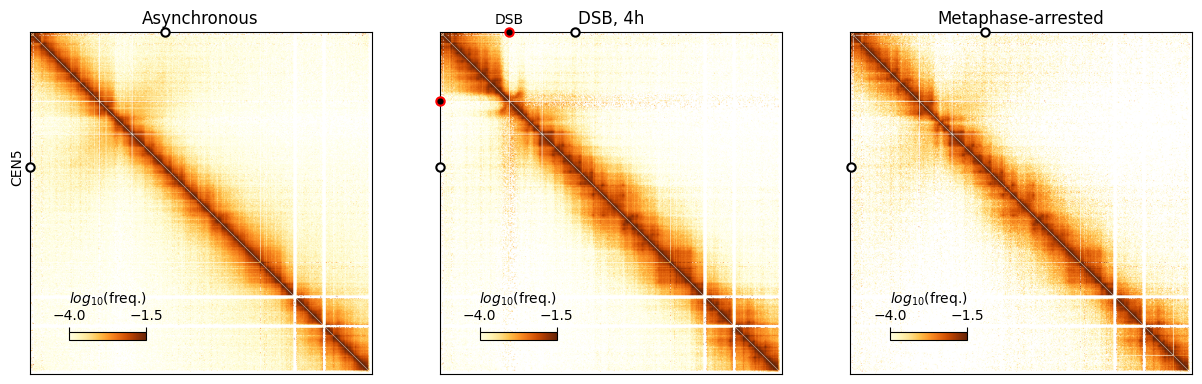

In [12]:
# plot

# create plot area
f,axs = plt.subplots(figsize=(15,4), ncols=3)

# for each sample submatrix
for i,smat in enumerate(submats):

    # plot matrix
    ax = axs[i]
    im = ax.imshow(np.log10(hcv.sparse_to_dense(smat)),
                   cmap=cmap, vmax=-1.5, vmin=-4)

    # remove axis ticks
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # add annotations of loci of interest
    # centromere
    cenpos = [0,np.median(loci[i]['cen5'])]
    ax.plot(
        cenpos, np.flip(cenpos), # position
        'o', markerfacecolor='white', markeredgecolor='black', markeredgewidth=1.5, # formatting
        clip_on=False, zorder=3) # clipping / layering

    # add centromere label for 1st plot
    if(i==0):
        ax.annotate(text="CEN5", xy=cenpos, xytext=(-10,cenpos[1]), annotation_clip=False,
                    verticalalignment='center', horizontalalignment='right', rotation='vertical')
    # Add DSB annotation for dsb sample
    if(i==1):
        dsbpos = [0,np.median(loci[i]['dsb'])]
        ax.plot(dsbpos, np.flip(dsbpos),
                'o', markerfacecolor='black', markeredgecolor='red', markeredgewidth=1.5,
                clip_on=False, zorder=3)
        ax.annotate(text="DSB", xy=np.flip(dsbpos), xytext=(dsbpos[1], -10), annotation_clip=False,
                    verticalalignment='bottom', horizontalalignment='center', rotation='horizontal')

    # add title
    ax.set_title(f'{labels[i]}')

    # add legend
    f.colorbar(im, ax=ax,
               label='$log_{10}$(freq.)', cmap=cmap, ticks = (-4, -1.5), # contents
               orientation='horizontal', fraction = 0.025, aspect=10, # look
               location='top', pad = -1, anchor=(.15,0)) # position
f.savefig(str(outputdir + "reprod_fig1c_piazza2021cohesin" + ".pdf"), format="pdf", dpi=300)
f.show()